In [6]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    log_loss, cohen_kappa_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.feature_selection import mutual_info_classif

from catboost import CatBoostClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

In [2]:
df = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [3]:
target = "CARDIO_DISEASE"

selected_features = [
    "AGE", "GENDER", "HEIGHT", "WEIGHT", "AP_HIGH", "AP_LOW",
    "CHOLESTEROL", "GLUCOSE", "SMOKE", "ALCOHOL", "PHYSICAL_ACTIVITY", "BMI"
]

X = df[selected_features].copy()
y = df[target].copy()

print("Selected feature count:", len(selected_features))
print(selected_features)

Selected feature count: 12
['AGE', 'GENDER', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY', 'BMI']


              Feature  MI Score
4             AP_HIGH  0.113171
5              AP_LOW  0.068525
0                 AGE  0.031011
6         CHOLESTEROL  0.024266
11                BMI  0.018038
3              WEIGHT  0.010603
10  PHYSICAL_ACTIVITY  0.008722
7             GLUCOSE  0.005335
1              GENDER  0.002143
2              HEIGHT  0.000727
8               SMOKE  0.000332
9             ALCOHOL  0.000000


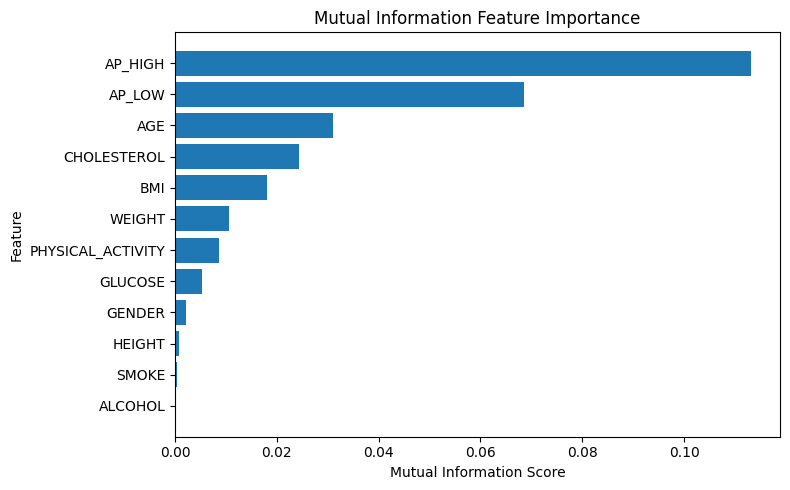

In [4]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    "Feature": selected_features,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False)

print(mi_df)

plt.figure(figsize=(8, 5))
plt.barh(mi_df["Feature"], mi_df["MI Score"])
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

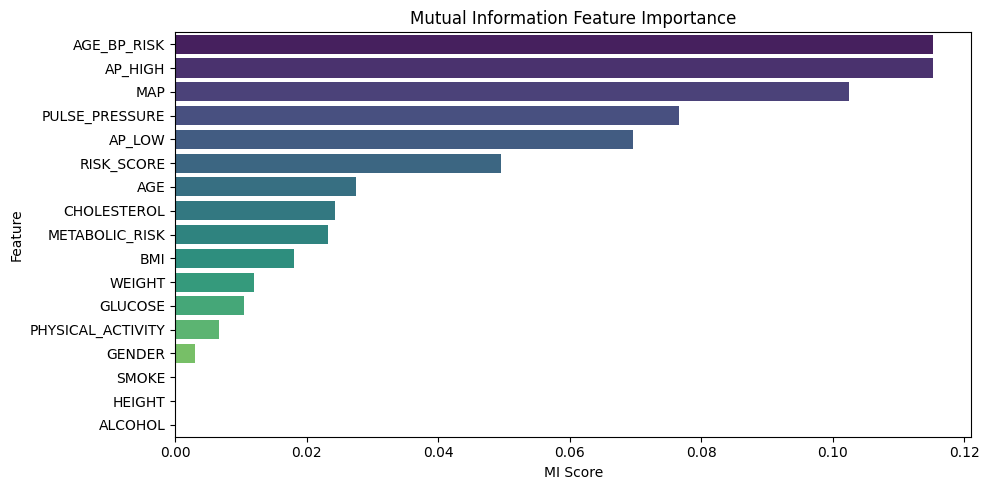

In [7]:
# Mutual Information feature importance
X= df.drop('CARDIO_DISEASE', axis=1)
y = df['CARDIO_DISEASE']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='viridis')
plt.title('Mutual Information Feature Importance')
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    """Print train/test metrics and return a dictionary for final comparison."""
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)

    train_prob = model.predict_proba(X_train_data)[:, 1]
    test_prob = model.predict_proba(X_test_data)[:, 1]

    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train_data, train_pred),
        "Test Accuracy": accuracy_score(y_test_data, test_pred),
        "Train AUC": roc_auc_score(y_train_data, train_prob),
        "Test AUC": roc_auc_score(y_test_data, test_prob),
        "Precision": precision_score(y_test_data, test_pred),
        "Recall": recall_score(y_test_data, test_pred),
        "F1": f1_score(y_test_data, test_pred),
        "Cohen Kappa": cohen_kappa_score(y_test_data, test_pred),
        "Log Loss": log_loss(y_test_data, np.column_stack([1 - test_prob, test_prob]))
    }

    print(f"===== {model_name} Evaluation =====")
    print(f"Train Accuracy: {results['Train Accuracy']:.4f}")
    print(f"Test Accuracy : {results['Test Accuracy']:.4f}")
    print(f"Train AUC     : {results['Train AUC']:.4f}")
    print(f"Test AUC      : {results['Test AUC']:.4f}")
    print(f"Precision     : {results['Precision']:.4f}")
    print(f"Recall        : {results['Recall']:.4f}")
    print(f"F1 Score      : {results['F1']:.4f}")
    print(f"Cohen Kappa   : {results['Cohen Kappa']:.4f}")
    print(f"Log Loss      : {results['Log Loss']:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_data, test_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_data, test_pred))

    return results, test_prob, test_pred


def plot_confusion_matrix_simple(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def tune_threshold(y_true, y_prob, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]

    tuned_pred = (y_prob >= best_threshold).astype(int)

    print(f"===== Threshold Tuning for {model_name} =====")
    print("Best threshold:", round(best_threshold, 4))
    print("Best F1 score :", round(f1_scores[best_idx], 4))
    print("Classification Report with Tuned Threshold:")
    print(classification_report(y_true, tuned_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, tuned_pred))

    return best_threshold, tuned_pred

In [10]:
# ---- MODEL 1: Gradient Boosting Machine (GBM) ----
gbm = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=20,
    subsample=0.85,
    validation_fraction=0.15,
    n_iter_no_change=15,
    tol=1e-4,
    random_state=42
)

gbm.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.85
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t`

===== Regularized GBM Evaluation =====
Train Accuracy: 0.7339
Test Accuracy : 0.7269
Train AUC     : 0.8032
Test AUC      : 0.7924
Precision     : 0.7439
Recall        : 0.6818
F1 Score      : 0.7115
Cohen Kappa   : 0.4533
Log Loss      : 0.5511
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6328
           1       0.74      0.68      0.71      6175

    accuracy                           0.73     12503
   macro avg       0.73      0.73      0.73     12503
weighted avg       0.73      0.73      0.73     12503

Confusion Matrix:
[[4879 1449]
 [1965 4210]]


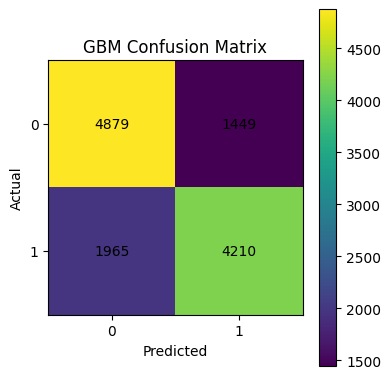

In [11]:
gbm_results, gbm_prob, gbm_pred = evaluate_model(
    gbm,
    X_train,
    y_train,
    X_test,
    y_test,
    "Regularized GBM"
)

plot_confusion_matrix_simple(y_test, gbm_pred, "GBM Confusion Matrix")

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gbm_cv = cross_val_score(
    gbm,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("GBM CV AUC scores:", gbm_cv)
print("GBM Mean CV AUC:", gbm_cv.mean())
print("GBM CV Std:", gbm_cv.std())

GBM CV AUC scores: [0.79655159 0.79064321 0.80021159 0.79775186 0.79782397]
GBM Mean CV AUC: 0.7965964427803336
GBM CV Std: 0.0032048110386486283


              Feature  Importance
4             AP_HIGH    0.649295
14         RISK_SCORE    0.125945
16        AGE_BP_RISK    0.110694
13                MAP    0.047872
11                BMI    0.018717
3              WEIGHT    0.008124
10  PHYSICAL_ACTIVITY    0.006560
6         CHOLESTEROL    0.006058
0                 AGE    0.006051
15     METABOLIC_RISK    0.005462
2              HEIGHT    0.004438
7             GLUCOSE    0.003424
9             ALCOHOL    0.002333
8               SMOKE    0.001962
12     PULSE_PRESSURE    0.001678
5              AP_LOW    0.000856
1              GENDER    0.000530


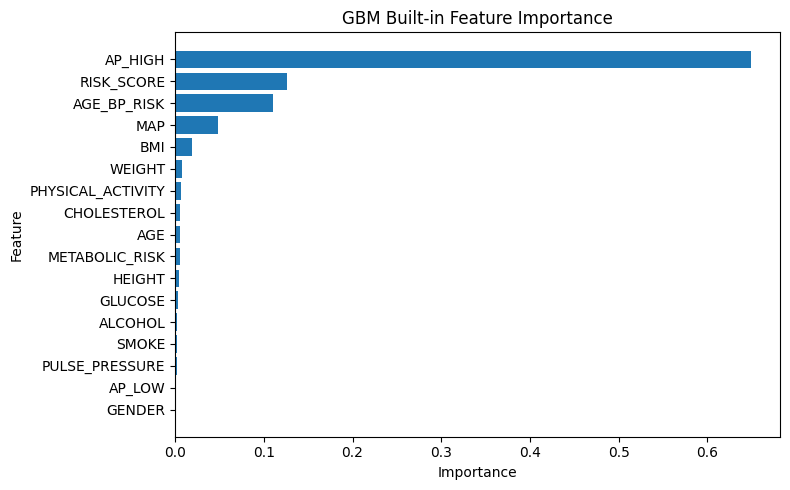

In [14]:
feature_names = X_train.columns.tolist()

gbm_fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gbm.feature_importances_
}).sort_values("Importance", ascending=False)

print(gbm_fi)

plt.figure(figsize=(8, 5))
plt.barh(gbm_fi["Feature"], gbm_fi["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("GBM Built-in Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


              Feature  Importance
4             AP_HIGH    0.113047
16        AGE_BP_RISK    0.026828
14         RISK_SCORE    0.025796
13                MAP    0.004428
11                BMI    0.002901
10  PHYSICAL_ACTIVITY    0.001932
6         CHOLESTEROL    0.000842
0                 AGE    0.000839
9             ALCOHOL    0.000800
7             GLUCOSE    0.000728
8               SMOKE    0.000606
15     METABOLIC_RISK    0.000598
1              GENDER    0.000291
3              WEIGHT    0.000186
5              AP_LOW    0.000080
12     PULSE_PRESSURE    0.000049
2              HEIGHT    0.000013


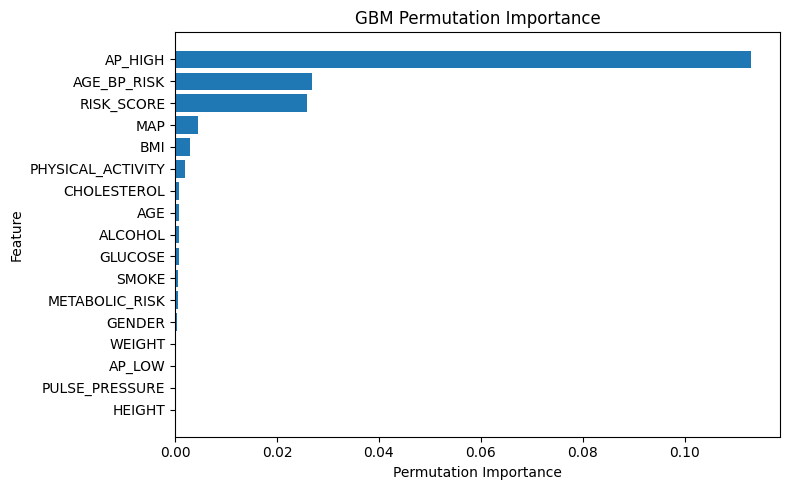

In [16]:
# GBM XAI 2: Permutation Importance
gbm_perm = permutation_importance(
    gbm,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

gbm_perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gbm_perm.importances_mean
}).sort_values("Importance", ascending=False)

print(gbm_perm_df)

plt.figure(figsize=(8, 5))
plt.barh(gbm_perm_df["Feature"], gbm_perm_df["Importance"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("GBM Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


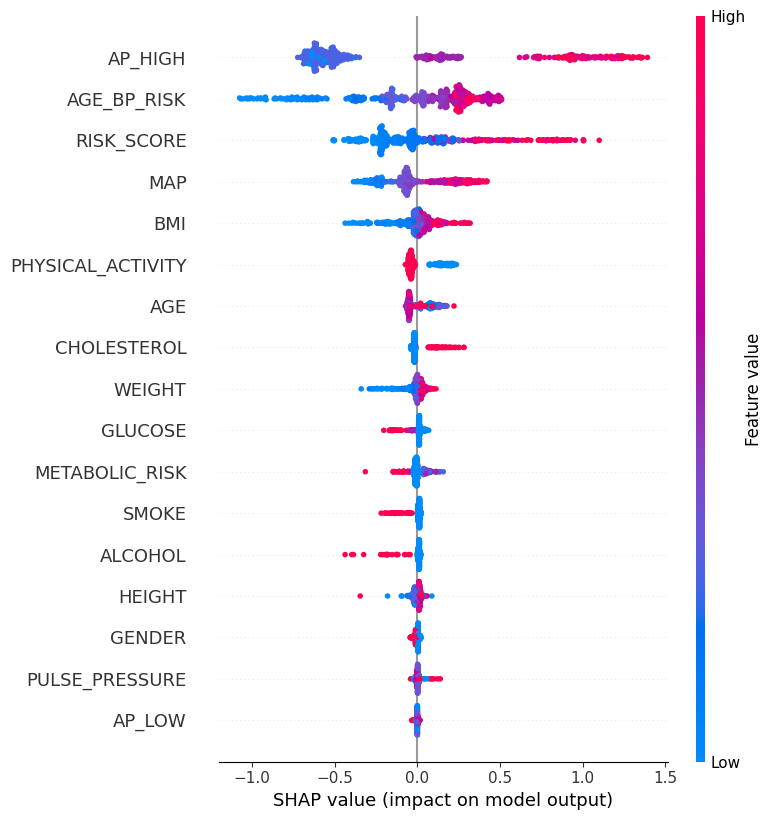

In [18]:
# GBM XAI 3: SHAP Summary Plot
# Use a sample to keep runtime reasonable.
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

gbm_explainer = shap.TreeExplainer(gbm)
gbm_shap_values = gbm_explainer.shap_values(X_test_sample)

shap.summary_plot(
    gbm_shap_values,
    X_test_sample,
    feature_names=feature_names
)


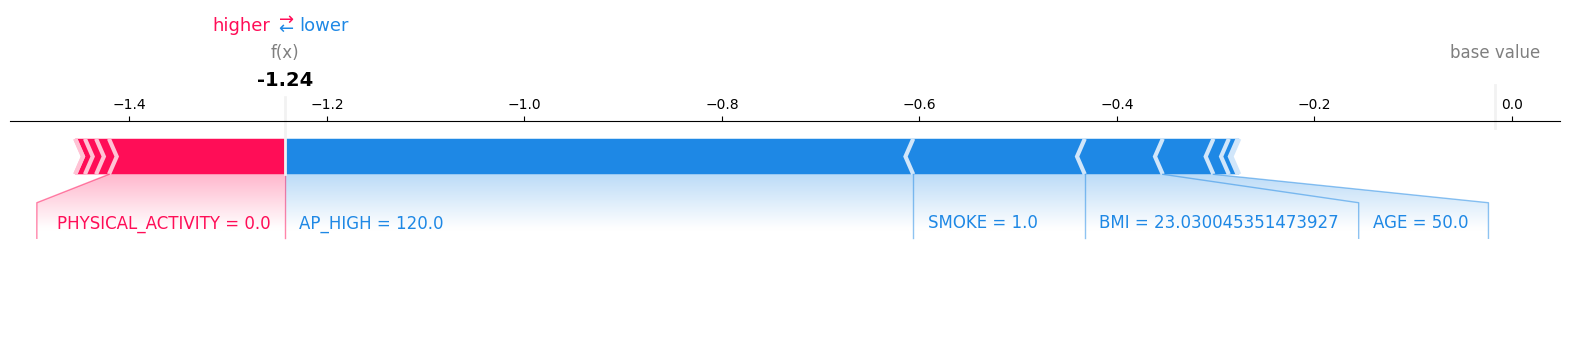

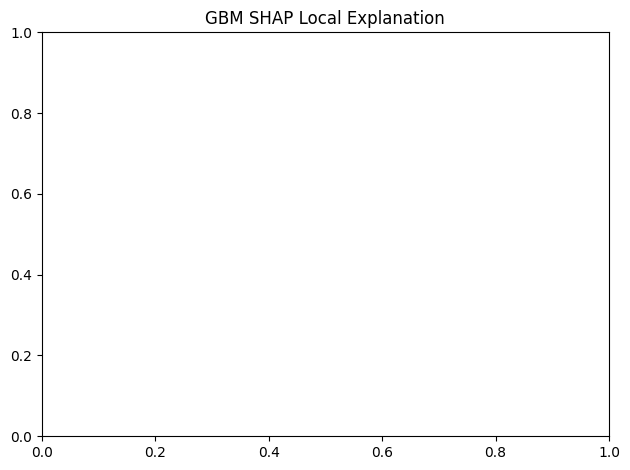

In [ ]:
# GBM XAI 4: SHAP Local Explanation
sample_index = 0

shap.force_plot(
    gbm_explainer.expected_value,
    gbm_shap_values[sample_index],
    X_test_sample.iloc[sample_index],
    feature_names=feature_names,
    matplotlib=True
)
plt.title("GBM SHAP Local Explanation")
plt.tight_layout()
plt.show()


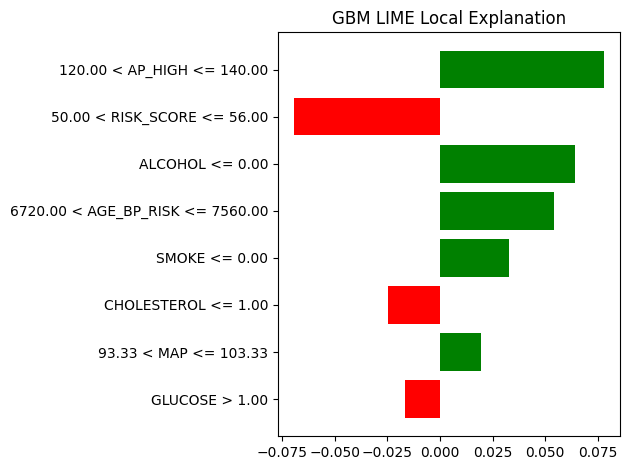

In [ ]:
# GBM XAI 5: LIME Local Explanation
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    mode="classification",
    random_state=42
)

lime_exp_gbm = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    gbm.predict_proba,
    num_features=8
)

lime_exp_gbm.as_pyplot_figure()
plt.title("GBM LIME Local Explanation")
plt.tight_layout()
plt.show()


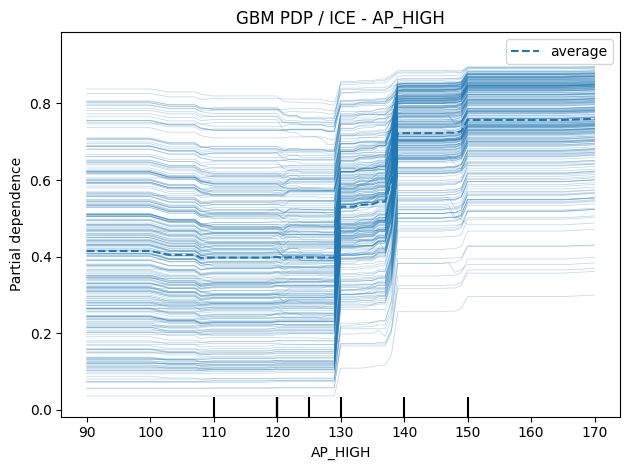

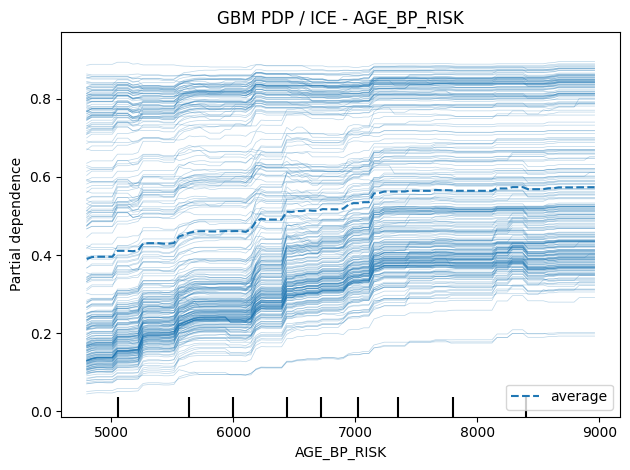

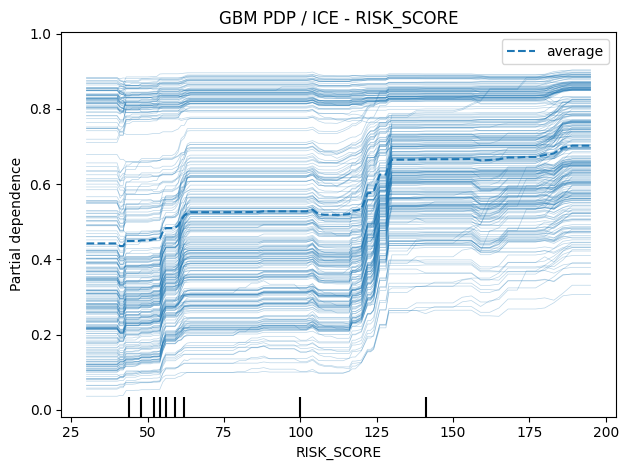

In [23]:
# GBM XAI 6: PDP / ICE
gbm_top_features = gbm_perm_df["Feature"].head(3).tolist()
X_test_float = X_test.astype(float)

for feature in gbm_top_features:
    PartialDependenceDisplay.from_estimator(
        gbm,
        X_test_float,
        features=[feature],
        kind="both",
        subsample=300,
        random_state=42
    )
    plt.title(f"GBM PDP / ICE - {feature}")
    plt.tight_layout()
    plt.show()
